# 实验三
### 1.随机生成一个10x15的高斯矩阵，均值为自己学号后两位，方差为1。对该矩阵分别进行LU、QR、奇异值，并展示分解结果。

In [8]:
import numpy as np
import scipy.linalg as la

# --- 1. 设置参数 ---
mean = 27 # 均值
variance = 1# 方差
std_dev = np.sqrt(variance) # 标准差也为1
rows = 10
cols = 15

A = np.random.normal(loc=mean, scale=std_dev, size=(rows, cols))
print(f"--- 原始矩阵 A (10x15) ---")
print(f"均值={mean}, 方差={variance}")
print(A)
print("-" * 100 + "\n")


print(f"--- LU 分解 (A = P.T @ L @ U) ---")
P_lu, L, U = la.lu(A)

print("P (置换矩阵, 10x10):")
print(P_lu)
print("\nL (下三角矩阵, 10x10):")
print(L)
print("\nU (上三角矩阵, 10x15):")
print(U)
print("-" * 100 + "\n")

print(f"--- QR 分解 (A = Q @ R) ---")
Q, R = la.qr(A, mode='full') 

print("Q (正交矩阵, 10x10):")
print(Q)
print("\nR (上三角矩阵, 10x15):")
print(R)
print("-" * 100 + "\n")

print(f"--- 奇异值分解 SVD (A = U @ Sigma @ Vh) ---")
U_svd, s, Vh = la.svd(A, full_matrices=False) # 使用 "economy" SVD
print("U (左奇异向量矩阵, 10x10):")
print(U_svd)
print("\ns (奇异值, 10个):")
print(s)
print("\nVh (V的转置, 右奇异向量矩阵, 10x15):")
print(Vh)
print("-" * 100 + "\n")

--- 原始矩阵 A (10x15) ---
均值=27, 方差=1
[[26.85357713 28.16216954 27.57171212 24.79564509 27.58229785 28.70261615
  26.4178442  26.76423994 26.35791505 29.42902555 26.6808647  26.19521523
  27.52182004 28.67380911 26.9894708 ]
 [26.60846038 27.0076873  27.11626962 25.95361405 26.83072491 27.02955588
  28.30571537 27.94341774 27.25398184 26.46579007 27.22004103 27.72087489
  25.37604187 28.85114078 25.84887132]
 [27.40125857 26.23850352 28.40176036 26.54023148 26.03826589 25.4898632
  24.44085706 25.29832309 27.04054538 26.14303253 27.14078718 25.61912971
  27.42071003 26.04224802 26.2784326 ]
 [26.63651417 27.03102825 26.97682691 27.23059796 25.68575289 27.01568844
  25.49041197 25.19082126 25.56954433 26.21940071 26.89989925 28.7220114
  26.3720582  25.82988619 26.50019231]
 [27.54406263 25.45406923 26.72135478 28.13889417 26.83594263 26.57319502
  26.72560291 27.0175427  25.88565684 27.72324341 27.50112668 27.77587685
  26.20804196 26.70014569 27.64061495]
 [28.8035131  27.59279045 27.244

### 2. min Z = - X1 - 0.8X2 - 1.2X3, 约束：X1 –X2 + X3 <= 30, 3X1 + 2X2 + 4X3 <=42,3X1 + 2X2 <= 30,X1, X2 , X3 >=0。并找到其中有效约束。

In [9]:
import numpy as np
from scipy.optimize import linprog

# 目标函数: min Z = -X1 - 0.8*X2 - 1.2*X3
c = [-1, -0.8, -1.2]
#约束条件
A_ub = np.array([
    [1, -1, 1],
    [3, 2, 4],
    [3, 2, 0]
])
b_ub = np.array([30, 42, 30])
# 变量边界: X1, X2, X3 >= 0
x1_bounds = (0, None)# (0, None) 表示 0 <= X <= 无穷大
x2_bounds = (0, None)
x3_bounds = (0, None)
bounds = [x1_bounds, x2_bounds, x3_bounds]

# 求解
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')


# 打印结果
print("--- 线性规划求解结果 ---")
print(res)
print("-" * 100 + "\n")

if res.success:
    print("求解成功!")
    print(f"最优目标函数值 (Min Z) = {res.fun:.4f}")
    print(f"最优解 (X1, X2, X3):")
    print(f"  X1 = {res.x[0]:.4f}")
    print(f"  X2 = {res.x[1]:.4f}")
    print(f"  X3 = {res.x[2]:.4f}")
    print("-" * 100 + "\n")

    # 4. 寻找有效约束
    print("--- 有效约束分析 ---")
    
    constraint_names = [
        "约束1: X1 - X2 + X3 <= 30",
        "约束2: 3*X1 + 2*X2 + 4*X3 <= 42",
        "约束3: 3*X1 + 2*X2 <= 30"
    ]
    
    # 检查不等式约束
    # res.slack 存储了松弛量 (b_ub - A_ub @ x)
    # 松弛量接近 0 意味着约束是有效的
    tolerance = 1e-9  # 浮点数比较的容差
    effective_constraints = []
    print("检查不等式约束:")
    for i in range(len(b_ub)):
        slack = res.slack[i]
        print(f"  {constraint_names[i]}")
        print(f"    松弛量 (Slack) = {slack:.4f}")
        if slack < tolerance:
            print("    ==> 此约束为有效约束 (Binding)")
            effective_constraints.append(constraint_names[i])
        else:
            print("    ==> 此约束为无效约束 (Non-binding)")

    # 检查变量的边界约束
    print("\n检查变量边界约束 (>= 0):")
    for i in range(len(res.x)):
        constraint_name = f"边界约束: X{i+1} >= 0"
        print(f"  {constraint_name}")
        print(f"    变量值 = {res.x[i]:.4f}")
        # 如果变量的值等于其下界 0
        if np.isclose(res.x[i], 0, atol=tolerance):
            print("    ==> 此约束为有效约束 (Binding)")
            effective_constraints.append(constraint_name)
        else:
            print("    ==> 此约束为无效约束 (Non-binding)")
            
    print("\n--- 总结：所有有效约束 ---")
    if not effective_constraints:
        print("没有找到有效约束。")
    else:
        for constr in effective_constraints:
            print(f" * {constr}")

else:
    print(f"求解失败: {res.message}")

--- 线性规划求解结果 ---
        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -15.6
              x: [ 0.000e+00  1.500e+01  3.000e+00]
            nit: 0
          lower:  residual: [ 0.000e+00  1.500e+01  3.000e+00]
                 marginals: [ 2.000e-01  0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 4.200e+01  0.000e+00  0.000e+00]
                 marginals: [-0.000e+00 -3.000e-01 -1.000e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0
----------------------------------------------------------------------------------------------------

求解成功!
最优目标函数值 (Min Z) = -15.6000
最优解 (X1, X2, X3):
  X1 = 0.0000
  X2 = 15.0000
  X3 = 3.0000
----------------------------------------------------------------------

### 3. 对于函数f(x) = (x2-5x+3)exp(-4x)cosx, x = 0: 0.1:1,进行三种方式插值，并将插值曲线与原曲线绘制在同一个Figure窗口。

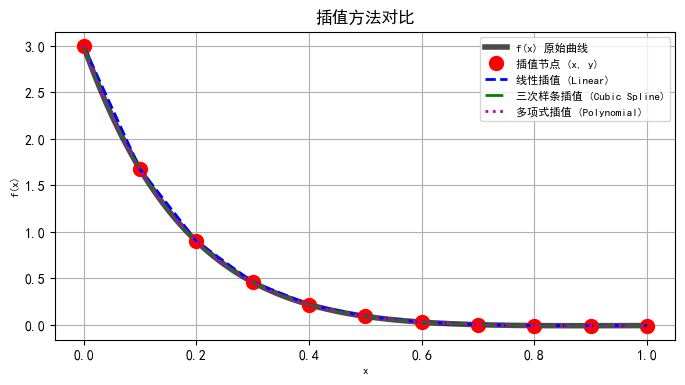

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, BarycentricInterpolator
plt.rcParams['font.sans-serif'] = ['SimHei'] 
def f(x):
    return (x**2 - 5*x + 3) * np.exp(-4*x) * np.cos(x)
#插值节点，步长0.1
x_nodes = np.arange(0, 1.01, 0.1)
y_nodes = f(x_nodes)
#高密度取点
x_true = np.linspace(0, 1, 400)
y_true = f(x_true)


# --- 方法 1: 线性插值 ---
f_linear = interp1d(x_nodes, y_nodes, kind='linear')
y_linear = f_linear(x_true)

# --- 方法 2: 三次样条插值 ---
f_cubic = interp1d(x_nodes, y_nodes, kind='cubic')
y_cubic = f_cubic(x_true)

# --- 方法 3: 多项式插值 ---
f_poly = BarycentricInterpolator(x_nodes, y_nodes)
y_poly = f_poly(x_true)


# 5. 绘图
plt.figure(figsize=(8, 4))
# 绘制原始函数曲线
plt.plot(x_true, y_true, 'k-', linewidth=4, label='f(x) 原始曲线', alpha=0.7)
# 绘制插值节点
plt.plot(x_nodes, y_nodes, 'ro', markersize=10, label='插值节点 (x, y)')
# 绘制三种插值曲线
plt.plot(x_true, y_linear, 'b--', linewidth=2, label='线性插值 (Linear)')
plt.plot(x_true, y_cubic, 'g-.', linewidth=2, label='三次样条插值 (Cubic Spline)')
plt.plot(x_true, y_poly, 'm:', linewidth=2, label='多项式插值 (Polynomial)')

# 添加图例、标题和网格
plt.title('插值方法对比', fontsize=12)
plt.xlabel('x', fontsize=8)
plt.ylabel('f(x)', fontsize=8)
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

### 4. 统计自己过去12个月实际生活花费的数值，并拟合成一条一次、二次、三次曲线，三条曲线分别用不同颜色和线型展示在同一张图里。

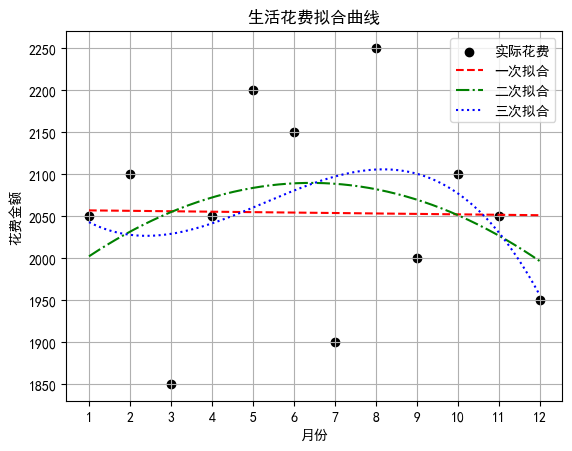

In [11]:
import numpy as np
import matplotlib.pyplot as plt

months = np.arange(1, 13)
expenses = np.array([
    2050, 2100, 1850, 2050, 2200, 2150,
    1900, 2250, 2000, 2100, 2050, 1950
])

x_smooth = np.linspace(months.min(), months.max(), 500)

# 一次
coeffs_1 = np.polyfit(months, expenses, 1)
y_linear = np.polyval(coeffs_1, x_smooth)

# 二次
coeffs_2 = np.polyfit(months, expenses, 2)
y_quadratic = np.polyval(coeffs_2, x_smooth)

# 三次
coeffs_3 = np.polyfit(months, expenses, 3)
y_cubic = np.polyval(coeffs_3, x_smooth)


plt.scatter(months, expenses, color='black', label='实际花费')

plt.plot(x_smooth, y_linear, 'r--', label='一次拟合')
plt.plot(x_smooth, y_quadratic, 'g-.', label='二次拟合')
plt.plot(x_smooth, y_cubic, 'b:', label='三次拟合')

plt.title('生活花费拟合曲线')
plt.xlabel('月份')
plt.ylabel('花费金额')
plt.xticks(months)  # 让X轴显示1-12
plt.legend()
plt.grid(True)
plt.show()

### 5. 求解三重积分∫（-0.5，1）∫（0，0.5）∫（-0.5pi,pi）(y sinx exp(x)+z cosx x2)dxdydz.

In [12]:
import numpy as np
from scipy.integrate import tplquad

def function(z, y, x):
    return y * np.sin(x) * np.exp(x) + z * np.cos(x) * x**2

# 定义上下限
x_min, x_max = -np.pi/2, np.pi
y_min, y_max = 0, 0.5
z_min, z_max = -0.5, 1.0

result, error = tplquad(
    function,
    x_min, x_max,
    y_min, y_max,
    z_min, z_max
)

print(f"数值结果: {result}")
print(f"估算误差: {error}")

数值结果: 1.0984691058108318
估算误差: 6.807031615366822e-14


### 6. 求微分方程 xy’+ y – exp(x) = 0,在初始条件y(1) = 2 exp下的特解，并画出解函数的图形。

--- 求解成功 ---
特解为: Eq(y(x), (exp(x) + E)/x)


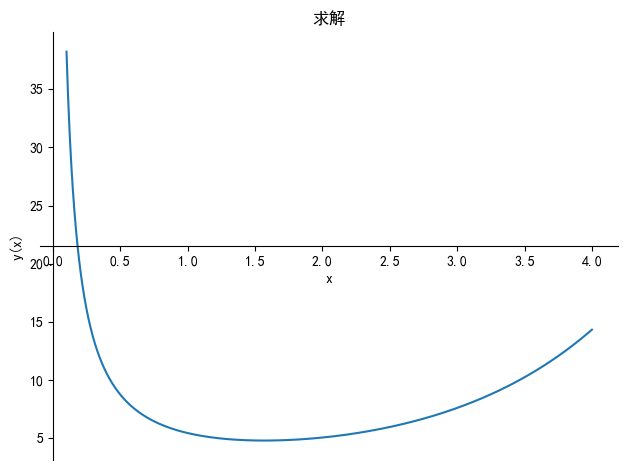

In [13]:
import sympy as sp

# 1. 定义符号
x = sp.symbols('x')
y = sp.Function('y')

# 2. 定义微分方程: xy' + y - exp(x) = 0
eq = sp.Eq(x * y(x).diff(x) + y(x) - sp.exp(x), 0)

# 3. 定义初始条件: y(1) = 2e
# sp.E 代表常数 e
ics = {y(1): 2 * sp.E}

# 4. 求解特解
particular_solution = sp.dsolve(eq, ics=ics)

# 5. 打印解
print(f"--- 求解成功 ---")
print(f"特解为: {particular_solution}")

# 6. 绘制图形
sp.plot(particular_solution.rhs, (x, 0.1, 4), 
        title="求解", 
        xlabel='x', 
        ylabel='y(x)')

### 7. 某人进行射击，及每次命中的概率为0.1，独立射击50次，求击中10次以上且40次以下的概率。

In [14]:
from scipy.stats import binom

n = 50  # 射击次数
p = 0.1 # 命中概率

# P(10 < X < 40) 等价于 P(11 <= X <= 39)
# 我们可以用 P(X <= 39) - P(X <= 10) 来计算

# binom.cdf(k, n, p) 计算 X <= k 的概率
prob = binom.cdf(39, n, p) - binom.cdf(10, n, p)

print(f"试验次数 n={n}, 概率 p={p}")
print(f"击中10次以上且40次以下的概率 P(11 <= X <= 39) 为:")
print(f"{prob:.8f}")

试验次数 n=50, 概率 p=0.1
击中10次以上且40次以下的概率 P(11 <= X <= 39) 为:
0.00935460


### 8. 假设自己过去12个月实际生活花费的数值服从正态分布，请求出其均值和方差的极大似然估计。

In [15]:
import numpy as np

expenses = np.array([
    2050, 2100, 1850, 2050, 2200, 2150,
    1900, 2250, 2000, 2100, 2050, 1950
])

# 1. 均值的极大似然估计
mu_mle = np.mean(expenses)

# 2. 方差的极大似然估计 (np.var 默认 ddof=0, 即除以 n)
variance_mle = np.var(expenses)

print(f"数据 (n={len(expenses)}): \n{expenses}\n")
print(f"均值 (μ) 的极大似然估计: {mu_mle:.4f}")
print(f"方差 (σ^2) 的极大似然估计: {variance_mle:.4f}")

数据 (n=12): 
[2050 2100 1850 2050 2200 2150 1900 2250 2000 2100 2050 1950]

均值 (μ) 的极大似然估计: 2054.1667
方差 (σ^2) 的极大似然估计: 12690.9722
